In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_style()

- Le numéro pour les colonnes correspond aux fréquences
- modulus : stockage, l'autre c'est perte
- attention, ajouter les titres
- mettre en échelle log

In [56]:
def plot(data_name, export=False, title=None):
    from matplotlib.ticker import MultipleLocator

    df = pd.read_csv(f"{data_name}.csv", sep=";")

    freq = ["0,1", "1", "10"]
    temp = df["Temp(C)"]

    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

    # graduations plus resserées
    axes[2].xaxis.set_major_locator(MultipleLocator(10))
    axes[2].xaxis.set_minor_locator(MultipleLocator(2))

    for ax in axes:
        ax.grid(True, axis="x", which="major")
        ax.grid(True, axis="x", which="minor", alpha=0.5, linestyle="--")
        ax.grid(True, axis="y", which="major")
        ax.grid(True, axis="y", which="minor", alpha=0.5, linestyle="--")

    # Module de stockage
    for f in freq:
        axes[0].plot(temp, df[f"Modulus {f}"], "+", label=f"{f} Hz")

    axes[0].set_ylabel("Module de stockage (Pa) (log scale)")
    axes[0].set_yscale("log")
    axes[0].legend()

    if title:
        axes[0].set_title(title)
    else:
        axes[0].set_title(f"DMA - {data_name}")

    # Tan Delta
    for f in freq:
        axes[1].plot(temp, df[f"Tan Delta {f}"], "+", label=f"{f} Hz")

    axes[1].set_ylabel(r"$\tan (\delta)$")
    axes[1].legend()

    # Module de perte
    for f in freq:
        axes[2].plot(temp, df[f"Loss Modulus {f}"], "+", label=f"{f} Hz")

    axes[2].set_xlabel("Température (°C)")
    axes[2].set_ylabel("Module de perte (Pa) (log scale)")
    axes[2].set_yscale("log")
    axes[2].legend()

    plt.tight_layout()

    if export:
        plt.savefig(f"output/{data_name}.pdf")
        plt.savefig(f"output/{data_name}.svg")

    plt.show()

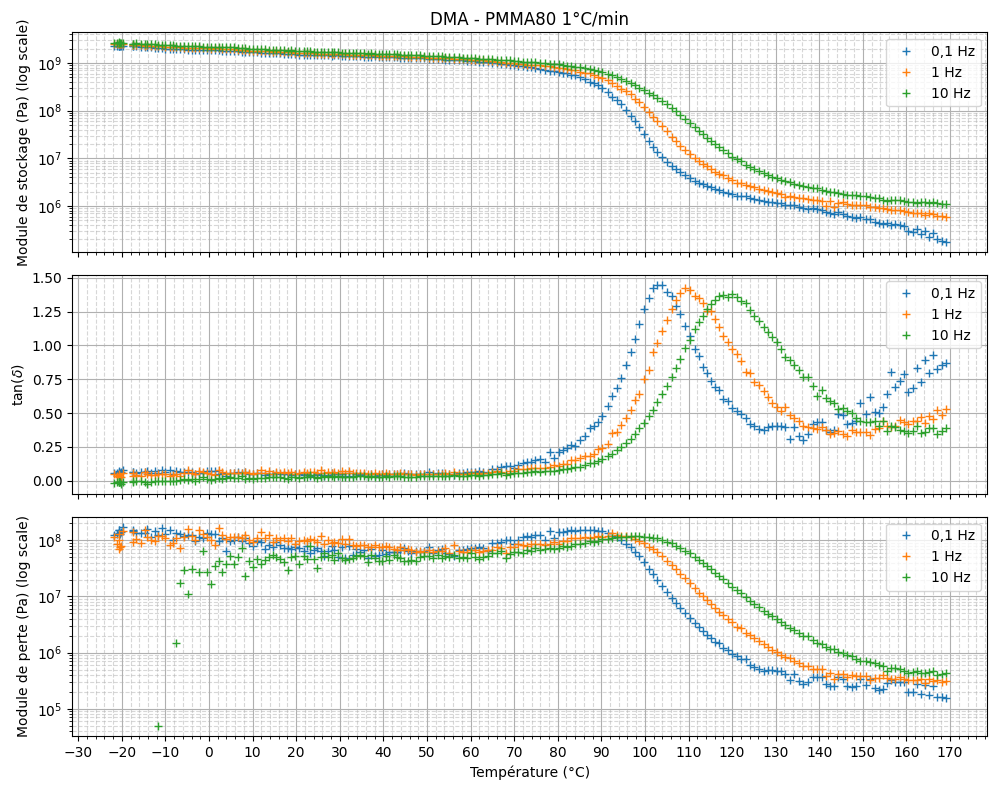

In [57]:
plot("PMMA80 1deg", title="DMA - PMMA80 1°C/min", export=True)

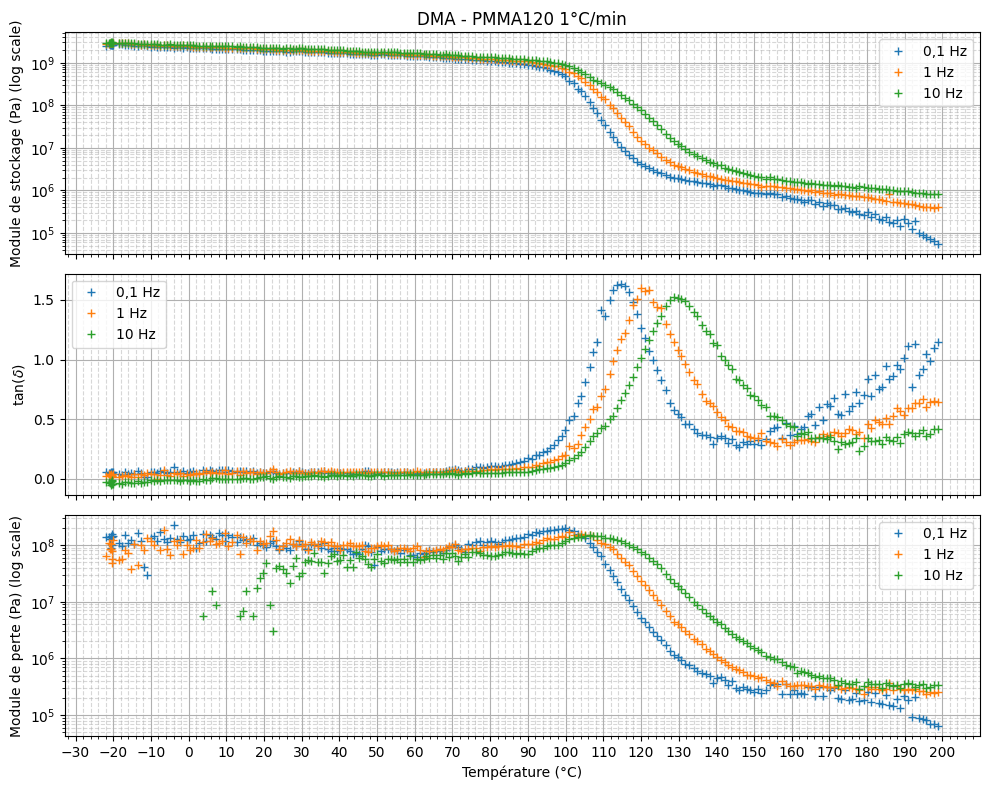

In [58]:
plot("PMMA120 1deg", title="DMA - PMMA120 1°C/min", export=True)

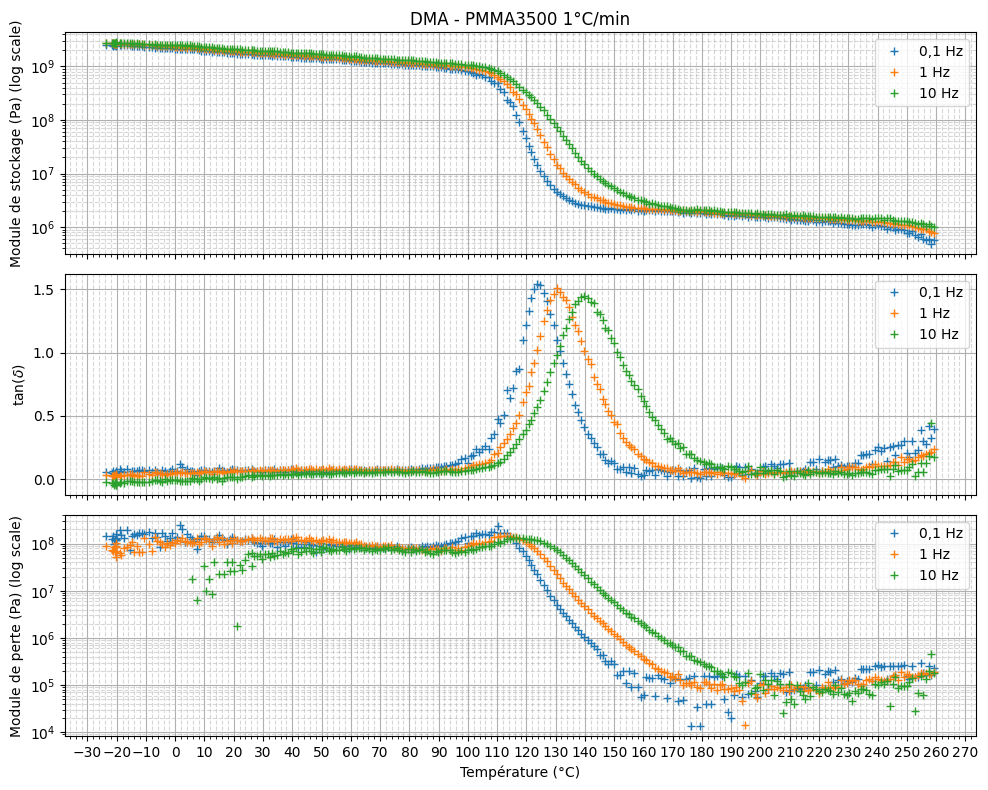

In [59]:
plot("PMMA3500 1deg", title="DMA - PMMA3500 1°C/min", export=True)

In [64]:
import numpy as np
import matplotlib.pyplot as plt

alpha_trans_temp = np.array([115, 120, 130])
freq = np.array([0.1, 1, 10])

f_0, alpha_trans_temp_0 = freq[0], alpha_trans_temp[0]
R = 8.314

ln_f_ratio = np.log(f_0 / freq)
invert_temp_diff = (1 / R) * (1 / alpha_trans_temp - 1 / alpha_trans_temp_0)

# Régression linéaire y = a*x + b
a, b = np.polyfit(invert_temp_diff, ln_f_ratio, 1)
x_fit = np.linspace(invert_temp_diff.min(), invert_temp_diff.max(), 100)
y_fit = a * x_fit + b

# Coefficient de détermination
y_pred = a * invert_temp_diff + b
ss_res = np.sum((ln_f_ratio - y_pred) ** 2)
ss_tot = np.sum((ln_f_ratio - np.mean(ln_f_ratio)) ** 2)
r2 = 1 - ss_res / ss_tot

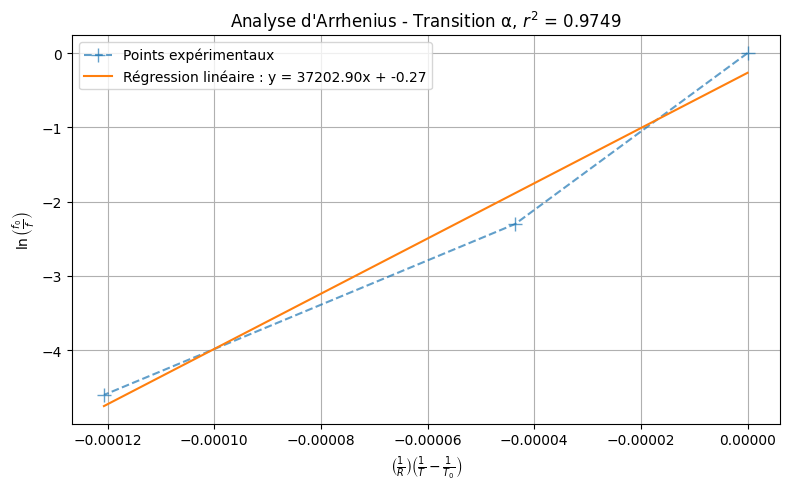

In [67]:
plt.figure(figsize=(8, 5))
plt.plot(invert_temp_diff, ln_f_ratio, "--+", alpha=0.7,
         markersize=10, label="Points expérimentaux")
plt.plot(x_fit, y_fit, label=f"Régression linéaire : y = {a:.2f}x + {b:.2f}")

plt.title(f"Analyse d'Arrhenius - Transition α, $r^2$ = {r2:.4f}")
plt.xlabel(
    r"$\left(\frac{1}{R}\right)\left(\frac{1}{T} - \frac{1}{T_0}\right)$")
plt.ylabel(r"$\ln\left(\frac{f_0}{f}\right)$")

plt.grid()

plt.legend()
plt.tight_layout()
plt.savefig("output/arrhenius_analysis.pdf")
plt.savefig("output/arrhenius_analysis.svg")

plt.show()